# Why Do Trig Ratios Come From a Unit Circle?

From the triangle notebook, you had a sharp observation:

> *When $\beta = 90°$, side $a$ is vertical — it IS the height. On the unit circle, $\sin 90° = 1$. Makes sense! But as I pull the leg and decrease $\beta$, I'm creating new heights all the time. Those heights are just straight vertical lines — why does that give a circle, not a straight-line path?*

You're seeing two **different things** and conflating them. This notebook untangles them:

| Thing | What it is | Shape |
|---|---|---|
| **Each height** (the blue dashes from the triangle notebook) | A vertical line from $C$ down to the base | A straight line segment ✓ |
| **The path traced by** $C$ | Where the *tip* of the stick ends up at each angle | **A circle** |

The heights are just the **y-coordinates** of points on the circle. The *circle* is the locus of $C$ itself.

Four blocks below show exactly why — and how $\sin$ and $\cos$ fall out naturally.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Arc

plt.rcParams['figure.dpi'] = 110


## Block 1 — The path of $C$ vs. the heights: two different things

Rotate a fixed-length stick around $B$. At each angle you get:

- A **height line** (vertical dashed segment from $C$ straight down) — these are indeed straight lines.
- The **position of $C$** itself — this traces a circle.

Watch the right panel: the tips of all the height lines together form a curve — that curve is the circle.
The heights are just the **y-coordinates** being read off the circle at each angle.


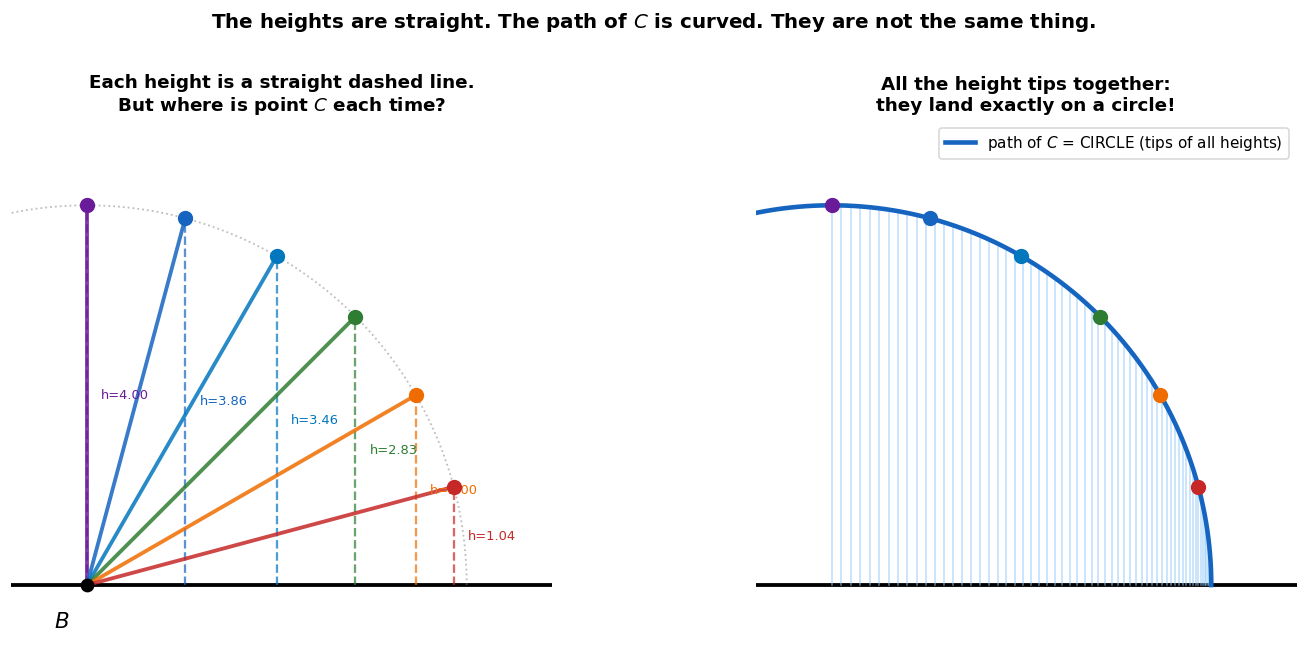

In [2]:
# === BLOCK 1: Heights are straight lines; the PATH of C is a circle ===

r = 4.0
angles_deg = [90, 75, 60, 45, 30, 15]
colors = ['#6A1B9A', '#1565C0', '#0277BD', '#2E7D32', '#EF6C00', '#C62828']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: the stick at each angle, with height lines ----
ax = axes[0]
ax.axhline(0, color='black', lw=2.5)
ax.plot(0, 0, 'ko', ms=8, zorder=6)
ax.text(-0.35, -0.45, '$B$', fontsize=14, fontweight='bold')

# faint full circle (the locus)
th = np.linspace(0, np.pi, 300)
ax.plot(r * np.cos(th), r * np.sin(th), color='gray', lw=1.2, ls=':', alpha=0.5)

for beta_deg, col in zip(angles_deg, colors):
    beta = np.radians(beta_deg)
    C = np.array([r * np.cos(beta), r * np.sin(beta)])
    h = C[1]
    # the stick (side a)
    ax.plot([0, C[0]], [0, C[1]], color=col, lw=2.5, alpha=0.85)
    # height line (vertical projection)  ← these are the "straight lines" you saw
    ax.plot([C[0], C[0]], [0, C[1]], color=col, lw=1.5, ls='--', alpha=0.7)
    # tip of height
    ax.plot(*C, 'o', color=col, ms=9, zorder=5)
    ax.text(C[0] + 0.15, h / 2, f'h={h:.2f}', color=col, fontsize=8.5, va='center')

ax.set_xlim(-0.8, r + 0.9)
ax.set_ylim(-0.8, r + 0.9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Each height is a straight dashed line.\n'
             'But where is point $C$ each time?', fontsize=12, fontweight='bold')

# ---- RIGHT: overlay height lines to show their tips form a curve ----
ax = axes[1]
ax.axhline(0, color='black', lw=2.5)

# draw many heights at fine resolution
betas_fine = np.linspace(np.radians(5), np.radians(90), 60)
for beta in betas_fine:
    C = np.array([r * np.cos(beta), r * np.sin(beta)])
    ax.plot([C[0], C[0]], [0, C[1]], color='#90CAF9', lw=1.0, alpha=0.6)

# overlay the circle on top — THIS is where the tips of heights lie
ax.plot(r * np.cos(th), r * np.sin(th), color='#1565C0', lw=3,
        label='path of $C$ = CIRCLE (tips of all heights)')

# mark a few tips
for beta_deg, col in zip(angles_deg, colors):
    beta = np.radians(beta_deg)
    C = np.array([r * np.cos(beta), r * np.sin(beta)])
    ax.plot(*C, 'o', color=col, ms=9, zorder=5)

ax.set_xlim(-0.8, r + 0.9)
ax.set_ylim(-0.8, r + 0.9)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', fontsize=10)
ax.set_title('All the height tips together:\n'
             'they land exactly on a circle!', fontsize=12, fontweight='bold')

plt.suptitle('The heights are straight. The path of $C$ is curved. They are not the same thing.',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Block 2 — Why *must* the path be a circle? Pythagoras says so.

When you rotate the stick and keep it rigid, the **distance from $B$ to $C$ never changes**. Let $r = |BC|$.

No matter what angle $\beta$ you choose, the right triangle inside gives:

$$x^2 + y^2 = r^2$$

That equation — a fixed distance from the origin — **is the definition of a circle**.

Put another way: you aren't *creating* a circle by some clever choice. It's forced on you the moment you keep the stick length fixed. The circle is the only shape that satisfies "constant distance from a fixed point".

The $x$ and $y$ coordinates of $C$ at angle $\beta$ are:

$$\boxed{x = r\cos\beta, \qquad y = r\cos\beta}$$

Wait — let me write that correctly:

$$\boxed{x = r\cos\beta, \qquad y = r\sin\beta}$$

Check: $x^2 + y^2 = r^2\cos^2\beta + r^2\sin^2\beta = r^2(\cos^2\beta + \sin^2\beta) = r^2$ ✓


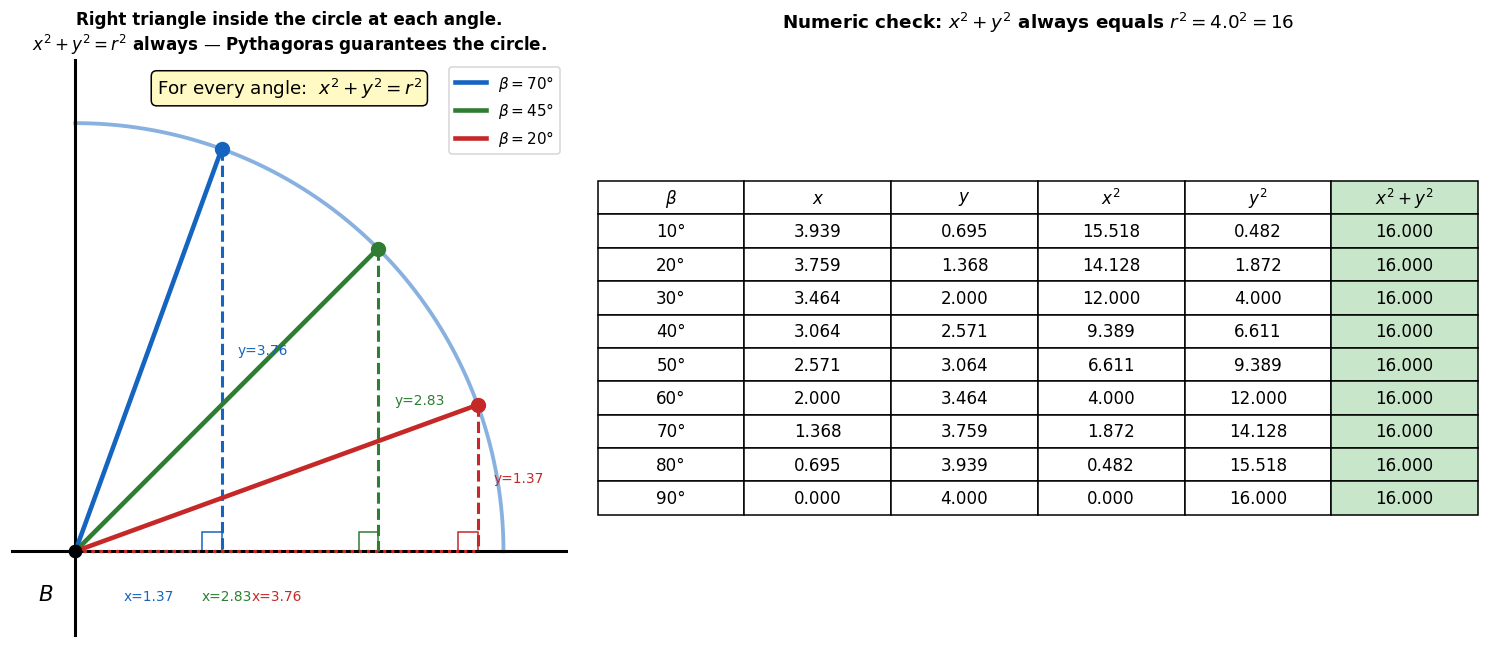

In [3]:
# === BLOCK 2: Pythagorean proof that x²+y²=r² at every angle ===

r = 4.0
beta_examples = [70, 45, 20]
colors_ex = ['#1565C0', '#2E7D32', '#C62828']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: show the right triangles inside the circle ----
ax = axes[0]
th = np.linspace(0, np.pi / 2, 300)
ax.plot(r * np.cos(th), r * np.sin(th), color='#1565C0', lw=2.5, alpha=0.5)
ax.axhline(0, color='black', lw=2)
ax.axvline(0, color='black', lw=2)
ax.plot(0, 0, 'ko', ms=8, zorder=6)
ax.text(-0.35, -0.45, '$B$', fontsize=14, fontweight='bold')

for beta_deg, col in zip(beta_examples, colors_ex):
    beta = np.radians(beta_deg)
    C = np.array([r * np.cos(beta), r * np.sin(beta)])
    D = np.array([C[0], 0])      # foot of perpendicular
    x, y = C

    # the right triangle
    ax.plot([0, C[0]], [0, C[1]], color=col, lw=3, label=f'$\\beta={beta_deg}°$')
    ax.plot([C[0], D[0]], [C[1], D[1]], color=col, lw=2, ls='--')
    ax.plot([0, D[0]], [0, D[1]], color=col, lw=2, ls=':')
    ax.plot(*C, 'o', color=col, ms=9, zorder=5)

    # label x and y
    ax.text(x / 2, -0.45, f'x={x:.2f}', ha='center', color=col, fontsize=9)
    ax.text(x + 0.15, y / 2, f'y={y:.2f}', va='center', color=col, fontsize=9)

    # verify x²+y²=r²
    sq = 0.18
    ax.add_patch(patches.Rectangle((D[0], 0), -sq, sq, fc='none', ec=col, lw=1))

ax.text(0.5, 0.97,
        'For every angle:  $x^2 + y^2 = r^2$',
        transform=ax.transAxes, ha='center', va='top', fontsize=12,
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))

ax.set_xlim(-0.6, r + 0.6)
ax.set_ylim(-0.8, r + 0.6)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', fontsize=10)
ax.set_title('Right triangle inside the circle at each angle.\n'
             '$x^2+y^2=r^2$ always — Pythagoras guarantees the circle.',
             fontsize=11, fontweight='bold')

# ---- RIGHT: numeric verification table ----
ax = axes[1]
ax.axis('off')
betas_check = np.arange(10, 91, 10)
rows = []
for b in betas_check:
    rad = np.radians(b)
    x = r * np.cos(rad); y = r * np.sin(rad)
    rows.append([f'{b}°', f'{x:.3f}', f'{y:.3f}',
                 f'{x**2:.3f}', f'{y**2:.3f}', f'{x**2+y**2:.3f}'])

col_labels = [r'$\beta$', r'$x$', r'$y$', r'$x^2$', r'$y^2$', r'$x^2+y^2$']
table = ax.table(cellText=rows, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.6)
# Highlight the last column (should all be r²=16)
for i in range(len(betas_check) + 1):
    table[i, 5].set_facecolor('#C8E6C9')

ax.set_title(f'Numeric check: $x^2+y^2$ always equals $r^2 = {r}^2 = {r**2:.0f}$',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## Block 3 — Shrink the radius to 1: the Unit Circle and where sin/cos come from

For a circle of radius $r$:

$$x = r\cos\beta, \qquad y = r\sin\beta$$

If we set $r = 1$ (the **unit circle**), then:

$$x = \cos\beta, \qquad y = \sin\beta$$

The coordinates *themselves* become the trig ratios. That is the **only** reason for the unit circle — it's the simplest case where you can read $\sin$ and $\cos$ directly off the axes without dividing by $r$.

For a general right triangle with hypotenuse $r$:

$$\sin\beta = \frac{y}{r} = \frac{\text{opposite}}{\text{hypotenuse}}, \qquad \cos\beta = \frac{x}{r} = \frac{\text{adjacent}}{\text{hypotenuse}}$$

These are ratios. On the unit circle, $r = 1$, so the ratio equals the coordinate.


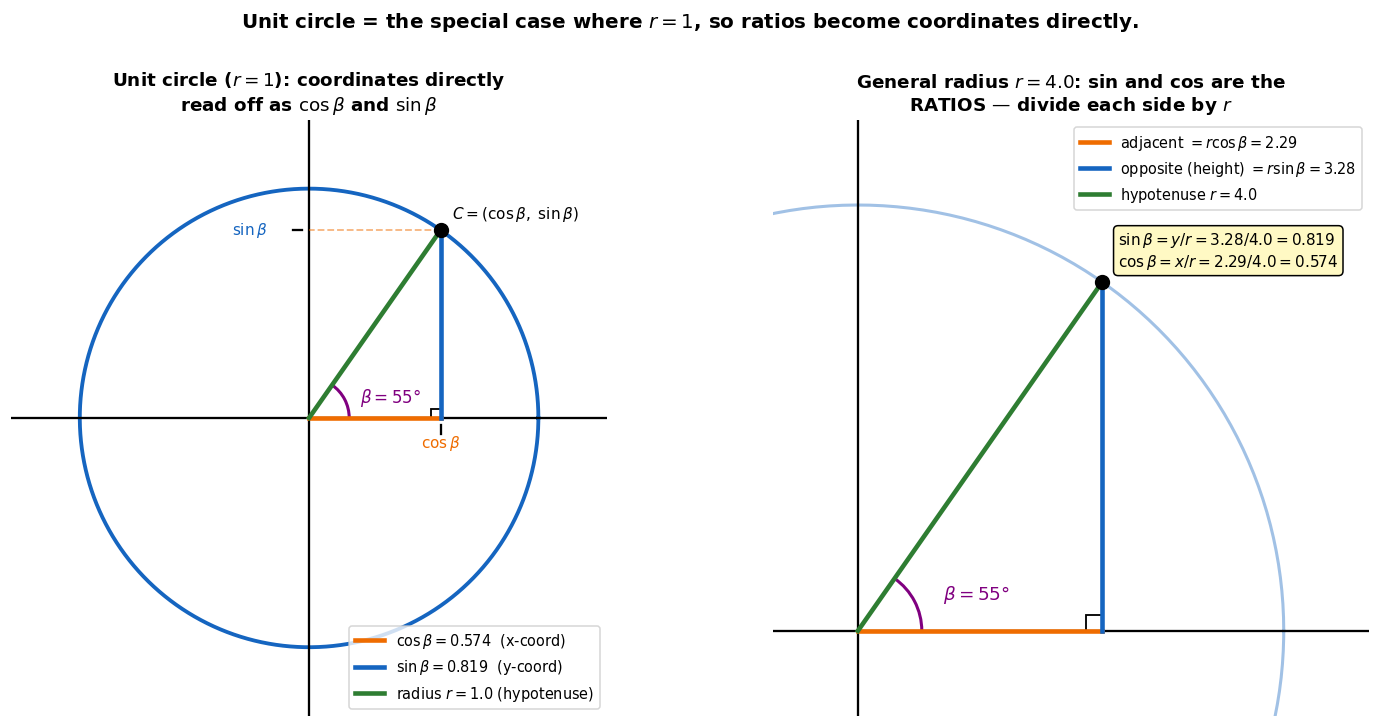

In [4]:
# === BLOCK 3: Unit circle — sin and cos as direct coordinates ===

beta_deg = 55
beta = np.radians(beta_deg)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

def draw_unit_circle_snapshot(ax, beta_deg, r=1.0, title=''):
    beta = np.radians(beta_deg)
    C = np.array([r * np.cos(beta), r * np.sin(beta)])
    x, y = C

    # Unit circle
    th = np.linspace(0, 2 * np.pi, 400)
    ax.plot(r * np.cos(th), r * np.sin(th), color='#1565C0', lw=2.5)

    # Axes
    ax.axhline(0, color='black', lw=1.5)
    ax.axvline(0, color='black', lw=1.5)

    # Right triangle
    ax.plot([0, x], [0, 0], color='#EF6C00', lw=3,
            label=f'$\\cos\\beta = {np.cos(beta):.3f}$  (x-coord)')
    ax.plot([x, x], [0, y], color='#1565C0', lw=3,
            label=f'$\\sin\\beta = {np.sin(beta):.3f}$  (y-coord)')
    ax.plot([0, x], [0, y], color='#2E7D32', lw=3,
            label=f'radius $r = {r}$ (hypotenuse)')

    # Projections onto axes (dashed)
    ax.plot([x, x], [y, 0], color='#1565C0', lw=1.2, ls='--', alpha=0.5)
    ax.plot([x, 0], [y, y], color='#EF6C00', lw=1.2, ls='--', alpha=0.5)

    # Point C
    ax.plot(*C, 'ko', ms=9, zorder=6)
    ax.text(x + 0.05, y + 0.05, f'$C = (\\cos\\beta,\\ \\sin\\beta)$', fontsize=10)

    # Angle arc
    arc = patches.Arc((0, 0), 0.35, 0.35, angle=0, theta1=0, theta2=beta_deg,
                       color='purple', lw=2)
    ax.add_patch(arc)
    ax.text(0.22, 0.07, f'$\\beta = {beta_deg}°$', color='purple', fontsize=11, fontweight='bold')

    # Right-angle marker
    sq = 0.04 * r
    ax.add_patch(patches.Rectangle((x - sq, 0), sq, sq, fc='none', ec='black', lw=1.2))

    # Axis ticks showing sin and cos
    ax.plot([x, x], [-0.07, -0.03], 'k-', lw=1.5)
    ax.text(x, -0.13, f'$\\cos\\beta$', ha='center', fontsize=10, color='#EF6C00', fontweight='bold')
    ax.plot([-0.07, -0.03], [y, y], 'k-', lw=1.5)
    ax.text(-0.18, y, f'$\\sin\\beta$', ha='right', fontsize=10, color='#1565C0', fontweight='bold',
            va='center')

    pad = 0.3
    ax.set_xlim(-r - pad, r + pad)
    ax.set_ylim(-r - pad, r + pad)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(loc='lower right', fontsize=9.5)
    ax.set_title(title, fontsize=12, fontweight='bold')

draw_unit_circle_snapshot(axes[0], beta_deg=55, r=1.0,
    title='Unit circle ($r=1$): coordinates directly\nread off as $\\cos\\beta$ and $\\sin\\beta$')

# Right panel: general radius r=4 to show the ratio interpretation
r_gen = 4.0
beta = np.radians(beta_deg)
ax = axes[1]
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(r_gen * np.cos(th), r_gen * np.sin(th), color='#1565C0', lw=2, alpha=0.4)
ax.axhline(0, color='black', lw=1.5)
ax.axvline(0, color='black', lw=1.5)

C = np.array([r_gen * np.cos(beta), r_gen * np.sin(beta)])
x, y = C
ax.plot([0, x], [0, 0], color='#EF6C00', lw=3,
        label=f'adjacent $= r\\cos\\beta = {x:.2f}$')
ax.plot([x, x], [0, y], color='#1565C0', lw=3,
        label=f'opposite (height) $= r\\sin\\beta = {y:.2f}$')
ax.plot([0, x], [0, y], color='#2E7D32', lw=3,
        label=f'hypotenuse $r = {r_gen}$')
ax.plot(*C, 'ko', ms=9, zorder=6)
ax.text(x + 0.15, y + 0.15,
        f'$\\sin\\beta = y/r = {y:.2f}/{r_gen} = {y/r_gen:.3f}$\n'
        f'$\\cos\\beta = x/r = {x:.2f}/{r_gen} = {x/r_gen:.3f}$',
        fontsize=10, color='black',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))

sq = 0.15
ax.add_patch(patches.Rectangle((x - sq, 0), sq, sq, fc='none', ec='black', lw=1.2))
arc = patches.Arc((0, 0), 1.2, 1.2, angle=0, theta1=0, theta2=beta_deg,
                   color='purple', lw=2)
ax.add_patch(arc)
ax.text(0.8, 0.3, f'$\\beta={beta_deg}°$', color='purple', fontsize=12, fontweight='bold')

pad = 0.8
ax.set_xlim(-pad, r_gen + pad)
ax.set_ylim(-pad, r_gen + pad)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', fontsize=9.5)
ax.set_title(f'General radius $r={r_gen}$: sin and cos are the\n'
             f'RATIOS — divide each side by $r$',
             fontsize=12, fontweight='bold')

plt.suptitle('Unit circle = the special case where $r=1$, so ratios become coordinates directly.',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Block 4 — Height is NOT proportional to angle: the sine curve

Your intuition *"small angle decrease → small height decrease"* is correct locally. But the rate at which height changes is **not constant** — it depends on where you are on the circle.

Think about it geometrically:
- Near $\beta = 90°$ (top of circle): moving sideways barely changes the height — $C$ is almost horizontal. Very **slow** height change.
- Near $\beta = 0°$ (side of circle): the circle is nearly vertical there — a small angle change drops $C$ a lot. Very **fast** height change.

This is why $\sin$ is curved, not linear. Equal angle steps give **unequal** height steps.

$$\frac{d}{d\beta}\sin\beta = \cos\beta$$

At $\beta = 90°$: $\cos 90° = 0$ — height barely changes. At $\beta = 0°$: $\cos 0° = 1$ — height changes fastest.


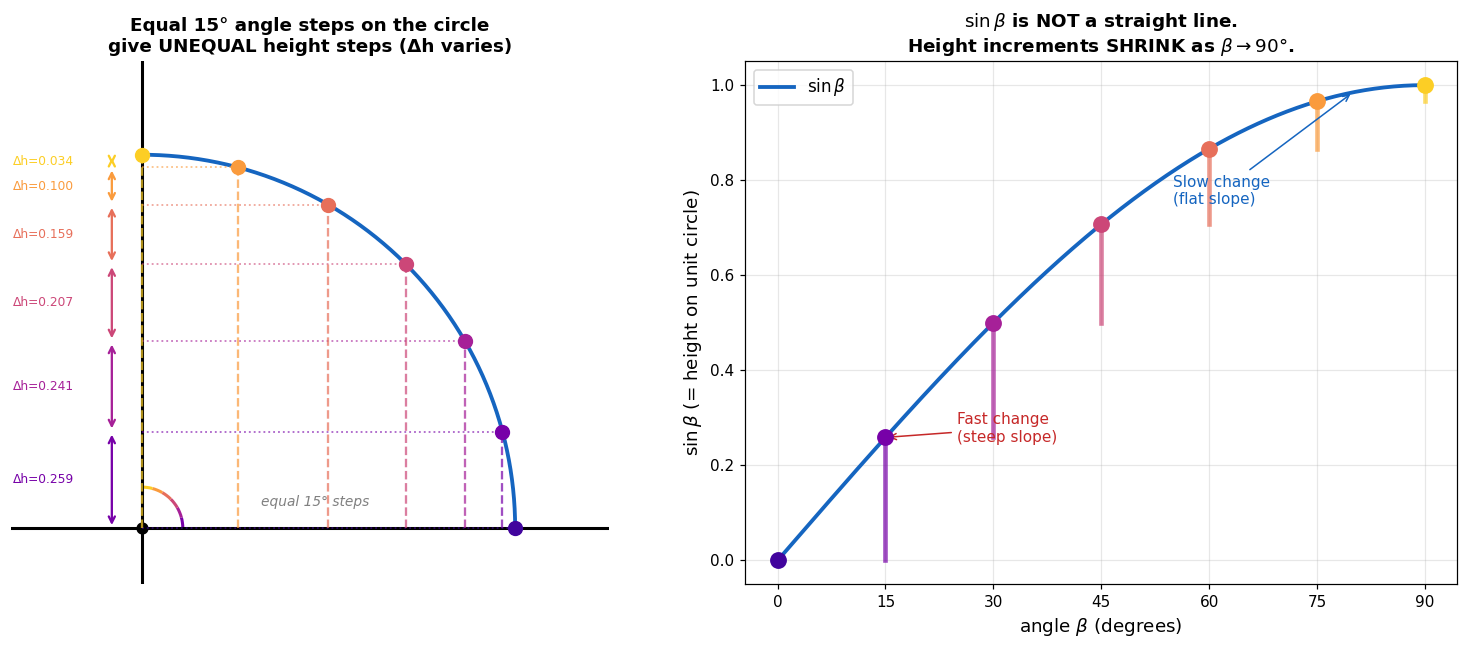

In [5]:
# === BLOCK 4: Equal angle steps → unequal height steps (sin is curved) ===

r = 1.0
step_deg = 15
angles_deg = np.arange(0, 91, step_deg)   # 0, 15, 30, 45, 60, 75, 90
colors_step = plt.cm.plasma(np.linspace(0.1, 0.9, len(angles_deg)))

fig = plt.figure(figsize=(14, 6))
ax_circle = fig.add_subplot(1, 2, 1)
ax_sine   = fig.add_subplot(1, 2, 2)

# ---- LEFT: circle with equal-angle steps marked ----
th = np.linspace(0, np.pi / 2, 300)
ax_circle.plot(np.cos(th), np.sin(th), color='#1565C0', lw=2.5)
ax_circle.axhline(0, color='black', lw=2)
ax_circle.axvline(0, color='black', lw=2)
ax_circle.plot(0, 0, 'ko', ms=7)

prev_h = None
for beta_deg, col in zip(angles_deg, colors_step):
    beta = np.radians(beta_deg)
    C = np.array([np.cos(beta), np.sin(beta)])
    h = C[1]

    # horizontal dotted line from C to y-axis (shows height)
    ax_circle.plot([0, C[0]], [h, h], color=col, lw=1.2, ls=':', alpha=0.6)
    # vertical line from circle to x-axis
    ax_circle.plot([C[0], C[0]], [0, h], color=col, lw=1.5, ls='--', alpha=0.7)
    ax_circle.plot(*C, 'o', color=col, ms=9, zorder=5)

    # bracket on y-axis showing the height increment
    if prev_h is not None:
        delta_h = h - prev_h
        mid_h = (prev_h + h) / 2
        ax_circle.annotate('', xy=(-0.08, h), xytext=(-0.08, prev_h),
                            arrowprops=dict(arrowstyle='<->', color=col, lw=1.5))
        ax_circle.text(-0.18, mid_h, f'Δh={delta_h:.3f}', ha='right', va='center',
                       color=col, fontsize=8)
    prev_h = h

# Angle arcs (equal steps)
for beta_deg, col in zip(angles_deg[1:], colors_step[1:]):
    arc = patches.Arc((0, 0), 0.22, 0.22, angle=0,
                       theta1=beta_deg - step_deg, theta2=beta_deg, color=col, lw=2)
    ax_circle.add_patch(arc)

ax_circle.text(0.32, 0.06, f'equal {step_deg}° steps', fontsize=9, color='gray',
               fontstyle='italic')

ax_circle.set_xlim(-0.35, 1.25)
ax_circle.set_ylim(-0.15, 1.25)
ax_circle.set_aspect('equal')
ax_circle.axis('off')
ax_circle.set_title(f'Equal {step_deg}° angle steps on the circle\ngive UNEQUAL height steps (Δh varies)',
                    fontsize=12, fontweight='bold')

# ---- RIGHT: sin(β) curve with equal angle steps marked ----
betas_fine = np.linspace(0, 90, 400)
ax_sine.plot(betas_fine, np.sin(np.radians(betas_fine)), color='#1565C0', lw=2.5,
             label=r'$\sin\beta$')

# Mark the equal steps and draw vertical Δh bars
prev_h = None
for beta_deg, col in zip(angles_deg, colors_step):
    h = np.sin(np.radians(beta_deg))
    ax_sine.plot(beta_deg, h, 'o', color=col, ms=10, zorder=5)
    if prev_h is not None:
        ax_sine.plot([beta_deg, beta_deg], [prev_h, h], color=col, lw=3, alpha=0.7)
    prev_h = h

# Shade to emphasise the shrinking increments
ax_sine.set_xlabel(r'angle $\beta$ (degrees)', fontsize=12)
ax_sine.set_ylabel(r'$\sin\beta$ (= height on unit circle)', fontsize=12)
ax_sine.set_title('$\\sin\\beta$ is NOT a straight line.\n'
                  'Height increments SHRINK as $\\beta \\to 90°$.',
                  fontsize=12, fontweight='bold')
ax_sine.set_xticks(angles_deg)
ax_sine.grid(alpha=0.3)
ax_sine.legend(fontsize=11)

# Annotate the fast/slow regions
ax_sine.annotate('Fast change\n(steep slope)', xy=(15, np.sin(np.radians(15))),
                 xytext=(25, 0.25), fontsize=10, color='#C62828',
                 arrowprops=dict(arrowstyle='->', color='#C62828'))
ax_sine.annotate('Slow change\n(flat slope)', xy=(80, np.sin(np.radians(80))),
                 xytext=(55, 0.75), fontsize=10, color='#1565C0',
                 arrowprops=dict(arrowstyle='->', color='#1565C0'))

plt.tight_layout()
plt.show()


## Now play with it — drag the angle

Use the slider to move $C$ around the unit circle and watch:

- The **height** ($\sin\beta$, blue) and **width** ($\cos\beta$, orange) read directly off the axes.
- Note how height changes **slowly** near $90°$ and **fast** near $0°$.
- At $\beta = 90°$: $\sin = 1$, $\cos = 0$ — $C$ is at the very top, $a$ IS the height (your original observation!).
- At $\beta = 0°$: $\sin = 0$, $\cos = 1$ — $C$ is on the x-axis, no height at all.


In [6]:
from ipywidgets import interact, FloatSlider

def show_unit_circle(beta_deg=55.0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # ---- LEFT: unit circle snapshot ----
    ax = axes[0]
    beta = np.radians(beta_deg)
    C = np.array([np.cos(beta), np.sin(beta)])
    sin_b, cos_b = C[1], C[0]

    # Full unit circle
    th = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(th), np.sin(th), color='#BDBDBD', lw=1.5)
    ax.axhline(0, color='black', lw=1.5)
    ax.axvline(0, color='black', lw=1.5)

    # Right triangle
    ax.plot([0, C[0]], [0, 0], color='#EF6C00', lw=4, label=f'cos β = {cos_b:.4f}')
    ax.plot([C[0], C[0]], [0, C[1]], color='#1565C0', lw=4, label=f'sin β = {sin_b:.4f}')
    ax.plot([0, C[0]], [0, C[1]], color='#2E7D32', lw=3, label=f'radius r = 1')

    # Projection dashes
    ax.plot([C[0], C[0]], [C[1], 0], color='#1565C0', lw=1.2, ls='--', alpha=0.5)
    ax.plot([C[0], 0], [C[1], C[1]], color='#EF6C00', lw=1.2, ls='--', alpha=0.5)

    # Point and label
    ax.plot(*C, 'ko', ms=10, zorder=6)
    ax.text(C[0] + 0.05, C[1] + 0.05, f'C = ({cos_b:.3f}, {sin_b:.3f})', fontsize=10)

    # Angle arc
    arc = patches.Arc((0, 0), 0.35, 0.35, angle=0, theta1=0, theta2=beta_deg,
                       color='purple', lw=2)
    ax.add_patch(arc)
    ax.text(0.22, 0.07, f'β = {beta_deg:.1f}°', color='purple', fontsize=11, fontweight='bold')

    # Axis markers
    ax.plot([C[0], C[0]], [-0.06, -0.02], 'k-', lw=1.5)
    ax.text(C[0], -0.12, f'{cos_b:.3f}', ha='center', fontsize=9, color='#EF6C00', fontweight='bold')
    ax.plot([-0.06, -0.02], [C[1], C[1]], 'k-', lw=1.5)
    ax.text(-0.17, C[1], f'{sin_b:.3f}', ha='right', va='center', fontsize=9,
            color='#1565C0', fontweight='bold')

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_title('Unit circle snapshot', fontsize=12, fontweight='bold')

    # ---- RIGHT: sin curve with current point highlighted ----
    ax2 = axes[1]
    betas = np.linspace(0, 360, 1000)
    ax2.plot(betas, np.sin(np.radians(betas)), color='#1565C0', lw=2.5, label=r'$\sin\beta$')
    ax2.plot(betas, np.cos(np.radians(betas)), color='#EF6C00', lw=2.5, label=r'$\cos\beta$', ls='--')
    ax2.axhline(0, color='black', lw=1)
    ax2.axvline(beta_deg, color='purple', lw=1.5, ls=':')
    ax2.plot(beta_deg, sin_b, 'o', color='#1565C0', ms=12, zorder=5)
    ax2.plot(beta_deg, cos_b, 's', color='#EF6C00', ms=12, zorder=5)
    ax2.set_xlabel(r'angle $\beta$ (degrees)', fontsize=11)
    ax2.set_ylabel('value', fontsize=11)
    ax2.set_title('sin and cos as functions of angle\n'
                  '(notice sin is the y-coord, cos is the x-coord)',
                  fontsize=11, fontweight='bold')
    ax2.set_xticks([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=11)
    ax2.text(0.02, 0.98,
             f'β = {beta_deg:.1f}°\nsin β = {sin_b:.4f}\ncos β = {cos_b:.4f}',
             transform=ax2.transAxes, va='top', fontsize=11,
             family='monospace',
             bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))

    plt.tight_layout()
    plt.show()

interact(show_unit_circle,
         beta_deg=FloatSlider(min=0, max=360, step=1, value=55,
                              description='β (deg)', style={'description_width': 'initial'}));


interactive(children=(FloatSlider(value=55.0, description='β (deg)', max=360.0, step=1.0, style=SliderStyle(de…

## One-line summary

$$\boxed{\cos\beta = \frac{x}{r}, \qquad \sin\beta = \frac{y}{r}}$$

- The **circle** arises because the stick has fixed length — Pythagoras forces $x^2 + y^2 = r^2$.
- The **straight height lines** you see are just the $y$-coordinates being projected — they don't form the circle, they *read off* the circle.
- $\sin$ and $\cos$ are the *ratios* of those coordinates to the radius. On the **unit circle** ($r=1$) the ratios equal the coordinates directly — that's the only reason for normalising.
- $\sin$ is curved (not linear) because the rate of height change, $\cos\beta$, varies: fast near $0°$, almost zero near $90°$.
